In [13]:
# dp = d['2-qubit']
# dp['1_tensor']['fid_SDP4'] = d['3-qubit']['1_tensor']['fid_SDP4']
dpv = {'1_tensor': {'fid_SDP': [0.9999921330227646,
   0.983632931558559,
   0.9624780792103131,
   0.9367051762873443,
   0.9068254600790959,
   0.8731896737794607,
   0.8418372803476928,
   0.8079219455596514,
   0.770416671352711,
   0.7325172356829232],
  'fid_sing': [1.0,
   0.9720237690148861,
   0.9436267430132539,
   0.9147687979209719,
   0.8854029962885428,
   0.8554738483549543,
   0.8249149571305296,
   0.7936457577630638,
   0.7615668851388537,
   0.7285533905932737]},
 '2_tensor': {'fid_SDP': [0.9999783617878478,
   0.9770326569336454,
   0.9655444534411557,
   0.9530833030852055,
   0.9444755827169921,
   0.9396308066804314,
   0.9377362481831646,
   0.9373441393883737,
   0.9369431713037439,
   0.9336754764841173],}}
dpv['2-qubit'] = dpv
dpv['3-qubit'] = {}
dpv['3-qubit']['2_tensor'] = {}
dpv['3-qubit']['2_tensor']['fid_SDP'] = d['3-qubit']['2_tensor']['fid_SDP4']

In [15]:
with open('fid_val', 'wb') as f:
    dump(dpv, f)
with open('fid_val', 'rb') as f:
    dpv = load(f)

In [2]:
from pickle import load, dump

with open('../values', 'rb') as f:
    d = load(f)
# with open('values', 'rb') as f:
#     d = load(f)
# dp['2-qubit']['2_tensor'] = d['2-qubit']['2_tensor']
d


# with open('values', 'wb') as f:
#     dump(dp, f)

{'2-qubit': {'1_tensor': {'fid_SDP4': [1.0000002606513139,
    0.959091741606458,
    0.9334100173570026,
    0.9100467841445019,
    0.8824664240916917,
    0.8530030812552947,
    0.8232051888438391,
    0.7923826273829591,
    0.760564601640475,
    0.7276655640877174],
   'fid_sing': [1.0,
    0.9720237690148861,
    0.9436267430132539,
    0.9147687979209719,
    0.8854029962885428,
    0.8554738483549543,
    0.8249149571305296,
    0.7936457577630638,
    0.7615668851388537,
    0.7285533905932737]},
  '2_tensor': {'fid_SDP4': [0.9999783617878478,
    0.9770326569336454,
    0.9655444534411557,
    0.9530833030852055,
    0.9444755827169921,
    0.9396308066804314,
    0.9377362481831646,
    0.9373441393883737,
    0.9369431713037439,
    0.9336754764841173],
   'fid_sing': [1.0,
    0.9858623331270115,
    0.9711940321028394,
    0.9559391283960025,
    0.9400314837989254,
    0.9233920551832872,
    0.905925147036854,
    0.8875131571026108,
    0.8680090088102077,
    0.8472

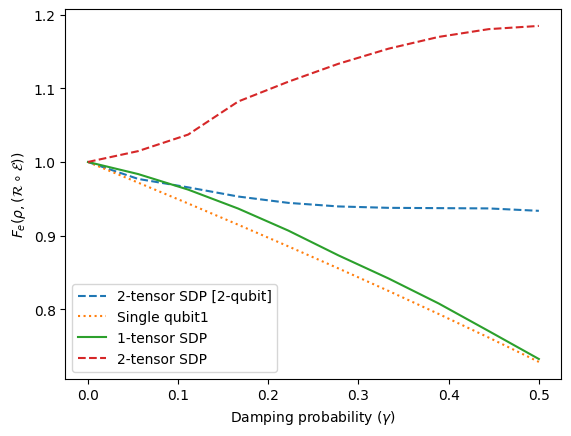

In [16]:
from matplotlib.pyplot import subplots, legend, savefig, show

damp_params = [i/(2*~-10) for i in range(10)]
_, ax = subplots(1, 1)
# ax.plot(damp_params, dpv['1_tensor']['fid_SDP'], label = "1-tensor SDP [2-qubit]")
ax.plot(damp_params, dpv['2-qubit']['2_tensor']['fid_SDP'], label = "2-tensor SDP [2-qubit]", ls = '--')
ax.plot(damp_params, dpv['2-qubit']['1_tensor']['fid_sing'], label = "Single qubit1", ls = ':')
ax.plot(damp_params, dpv['2-qubit']['1_tensor']['fid_SDP'], label = "1-tensor SDP")
ax.plot(damp_params, dpv['3-qubit']['2_tensor']['fid_SDP'], label = "2-tensor SDP", ls = '--')
ax.set_xlabel(r'Damping probability $(\gamma)$')
ax.set_ylabel(r'$F_e(\rho,(\mathcal{R}\circ\mathcal{E}))$')
legend()
show()

In [3]:
from time import sleep
from sharedmem import empty
from multiprocessing import Process, Manager, Array, Lock
from numpy import array, kron, zeros


def foo(l, data, name=''):
    print(type(data), data[:], name)
    l.acquire()
#     try:
    for _ in range(99):
        data += kron([[1, 0], [0, 1]], [[1, 0], [0, 1]])
    if data[0][0]%2:
        for i in range(99):
            data -= kron([[0, 1], [1, 0]], [[0, 1], [1, 0]])
#     finally:
    l.release()


if __name__ == "__main__":
    manager = Manager()
#     a = []
#     for _ in range(3):
    x = empty((4, 4))
    x[:] = zeros(4)
    lock = Lock()

    for i in range(5):
        Process(target = foo, args = (lock, x)).start()
#         time.sleep(5.0)

    print('Before waiting: ')
    print('x = {0}'.format(x[:]))

    sleep(5.0)
    print('After waiting: ')
    print('x = {0}'.format(x[:]))

<class 'sharedmem.sharedmem.anonymousmemmap'> <class 'sharedmem.sharedmem.anonymousmemmap'><class 'sharedmem.sharedmem.anonymousmemmap'><class 'sharedmem.sharedmem.anonymousmemmap'>[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]   
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]  [[ 99.   0.   0. -69.]
 [  0.  99. -69.   0.]
 [  0. -69.  99.   0.]
 [-70.   0.   0.  99.]]
 
<class 'sharedmem.sharedmem.anonymousmemmap'> [[ 396.    0.    0. -198.]
 [   0.  396. -198.    0.]
 [   0. -198.  396.    0.]
 [-198.    0.    0.  396.]] 
Before waiting: 
x = [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
After waiting: 
x = [[ 495.    0.    0. -297.]
 [   0.  495. -297.    0.]
 [   0. -297.  495.    0.]
 [-297.    0.    0.  495.]]


In [23]:
from pickle import load, dump

with open('../values', 'rb') as f:
    data = load(f)
data

{'1-qubit': {'2-tensor': {1: {'fid_SDP1': [1.00000842447587,
     0.9857148512789646,
     0.9705779954631333,
     0.9545190223625257,
     0.9374460285847634,
     0.9192502864257179,
     0.8998009769421595,
     0.8789365507489203,
     0.8564615059378227,
     0.8321284498192372],
    'fid_sing': [1.0,
     0.9720237690148861,
     0.9436267430132539,
     0.9147687979209719,
     0.8854029962885428,
     0.8554738483549543,
     0.8249149571305296,
     0.7936457577630638,
     0.7615668851388537,
     0.7285533905932737]},
   2: {'fid_SDP1': [1.0000008617609364,
     0.9857310288333616,
     0.970603526571263,
     0.9545610979385493,
     0.937501385158339,
     0.9192808918311872,
     0.8998191209979725,
     0.8789578065982937,
     0.8564670413083194,
     0.8321063834686588],
    'fid_sing': [1.0,
     0.9720237690148861,
     0.9436267430132539,
     0.9147687979209719,
     0.8854029962885428,
     0.8554738483549543,
     0.8249149571305296,
     0.7936457577630638,
   

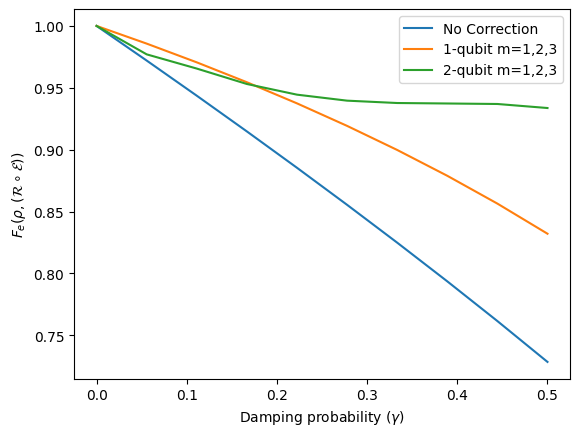

In [24]:
from matplotlib.pyplot import subplots, legend, savefig, show

damp_params = [i/(2*~-10) for i in range(10)]
_, ax = subplots(1, 1)
ax.plot(damp_params, data['2-qubit']['2-tensor'][3]['fid_sing'], label = "No Correction")
ax.plot(damp_params, data['1-qubit']['2-tensor'][1]['fid_SDP1'], label = "1-qubit m=1,2,3")
ax.plot(damp_params, data['2-qubit']['2-tensor'][1]['fid_SDP2'], label = "2-qubit m=1,2,3")
# ax.plot(damp_params, data['1-qubit']['2-tensor'][3]['fid_sing'], label = "1-qubit")
ax.set_xlabel(r'Damping probability $(\gamma)$')
ax.set_ylabel(r'$F_e(\rho,(\mathcal{R}\circ\mathcal{E}))$')
legend()
show()